<div style="border: 5px solid black; border-radius: 8px; padding: 20px;">

### **Course:** DSC630 — Predictive Analytics
### **Name:** Tim Hollis
### **Assignment:** Exercise 4.2
### **Date:** 04/09/2026
---
Note: The als_data.csv dataset was provided directly, so no citation was added.

</div>

### **Initial Setup:**

In [20]:
# Loading Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Global viz formatting
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

ROYAL_BLUE = '#4169E1'
PURPLE = '#4B0082'
GREEN = '#228B22'

# Load dataset
df = pd.read_csv('als_data.csv')

print('✅ Dataset loaded successfully!')
print(f'📐 Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()  # Adding space for readability
print(f'📋 Columns: {list(df.columns)}')

✅ Dataset loaded successfully!
📐 Shape: 2,223 rows x 101 columns

📋 Columns: ['ID', 'Age_mean', 'Albumin_max', 'Albumin_median', 'Albumin_min', 'Albumin_range', 'ALSFRS_slope', 'ALSFRS_Total_max', 'ALSFRS_Total_median', 'ALSFRS_Total_min', 'ALSFRS_Total_range', 'ALT.SGPT._max', 'ALT.SGPT._median', 'ALT.SGPT._min', 'ALT.SGPT._range', 'AST.SGOT._max', 'AST.SGOT._median', 'AST.SGOT._min', 'AST.SGOT._range', 'Bicarbonate_max', 'Bicarbonate_median', 'Bicarbonate_min', 'Bicarbonate_range', 'Blood.Urea.Nitrogen..BUN._max', 'Blood.Urea.Nitrogen..BUN._median', 'Blood.Urea.Nitrogen..BUN._min', 'Blood.Urea.Nitrogen..BUN._range', 'bp_diastolic_max', 'bp_diastolic_median', 'bp_diastolic_min', 'bp_diastolic_range', 'bp_systolic_max', 'bp_systolic_median', 'bp_systolic_min', 'bp_systolic_range', 'Calcium_max', 'Calcium_median', 'Calcium_min', 'Calcium_range', 'Chloride_max', 'Chloride_median', 'Chloride_min', 'Chloride_range', 'Creatinine_max', 'Creatinine_median', 'Creatinine_min', 'Creatinine_range

---
## Step 1: Remove Irrelevant Data

The dataset contains two administrative identifier columns, ID and SubjectID, which carry no clinical relevance to a patient's ALS condition. All remaining columns, including demographic variables such as age and gender, lab values, motor function subscores, and ALSFRS progression metrics, are retained as they may contribute meaningful signal to patient condition profiling.

In [21]:
# Remove irrelevant columns
cols_to_drop = ['ID', 'SubjectID']
df = df.drop(columns=cols_to_drop)

print('🗑️ Dropped administrative identifier columns: ID, SubjectID')
print(f'📐 Updated shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'\n❓ Missing values per column (top 10):')
print(df.isnull().sum().sort_values(ascending=False).head(10).to_string())
print(f'\n📊 Total missing values: {df.isnull().sum().sum():,}')

🗑️ Dropped administrative identifier columns: ID, SubjectID
📐 Updated shape: 2,223 rows x 99 columns

❓ Missing values per column (top 10):
Age_mean               0
Albumin_max            0
Albumin_median         0
Albumin_min            0
Albumin_range          0
ALSFRS_slope           0
ALSFRS_Total_max       0
ALSFRS_Total_median    0
ALSFRS_Total_min       0
ALSFRS_Total_range     0

📊 Total missing values: 0


---
## Step 2: Apply Standard Scaler

With no missing values present, we apply a standard scaler to normalize all features to a mean of 0 and standard deviation of 1. This is a necessary preprocessing step for K-means clustering, which is sensitive to the scale of input features. Without scaling, variables with larger numeric ranges would disproportionately influence cluster assignments.

In [22]:
# Apply Standard Scaler
scaler = StandardScaler()
scaled_array = scaler.fit_transform(df)

df_scaled = pd.DataFrame(scaled_array, columns=df.columns)

print('✅ Standard scaling applied successfully!')
print(
    f'📐 Scaled data shape: {df_scaled.shape[0]:,} rows x {df_scaled.shape[1]} columns')
print(f'\n📊 Sample means after scaling (should be near 0):')
print(df_scaled.mean().head(5).round(6).to_string())
print(f'\n📊 Sample std after scaling (should be near 1):')
print(df_scaled.std().head(5).round(6).to_string())

✅ Standard scaling applied successfully!
📐 Scaled data shape: 2,223 rows x 99 columns

📊 Sample means after scaling (should be near 0):
Age_mean         -0.0
Albumin_max      -0.0
Albumin_median   -0.0
Albumin_min      -0.0
Albumin_range     0.0

📊 Sample std after scaling (should be near 1):
Age_mean          1.000225
Albumin_max       1.000225
Albumin_median    1.000225
Albumin_min       1.000225
Albumin_range     1.000225


---
## Step 3: Silhouette Score Plot

To determine the optimal number of clusters for K-means, we calculate the silhouette score for a range of cluster values. The silhouette score measures how similar a point is to its own cluster compared to other clusters, ranging from -1 to 1 where higher values indicate better defined clusters. We plot these scores to identify the number of clusters that maximizes cluster cohesion and separation.

⏳ Calculating silhouette scores...
   k=2: silhouette score = 0.0787
   k=3: silhouette score = 0.0682
   k=4: silhouette score = 0.0708
   k=5: silhouette score = 0.0564
   k=6: silhouette score = 0.0708
   k=7: silhouette score = 0.0476
   k=8: silhouette score = 0.0492
   k=9: silhouette score = 0.0486
   k=10: silhouette score = 0.0383


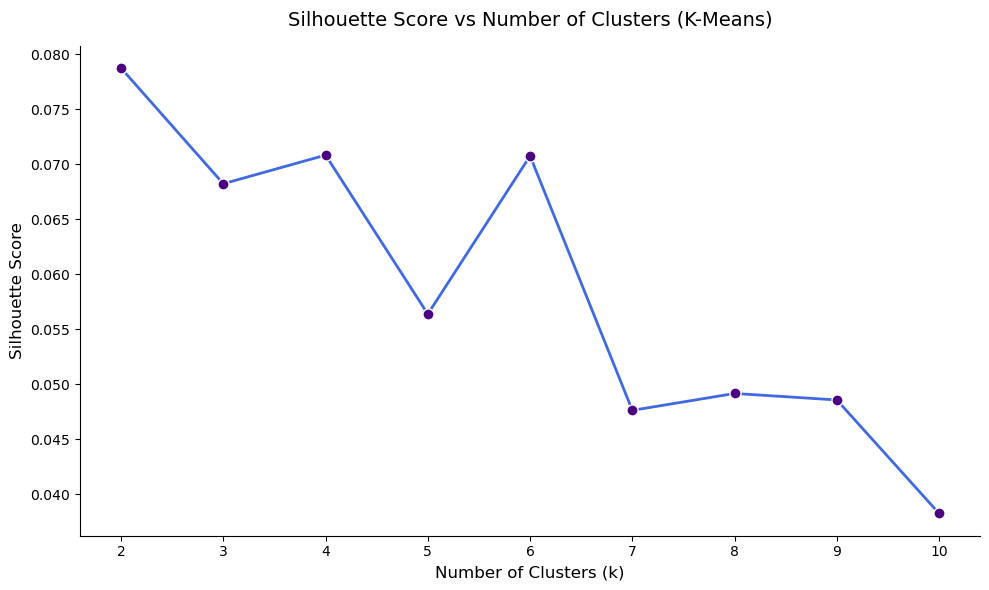


✅ Silhouette score plot complete.


In [23]:
# Silhouette score vs number of clusters
cluster_range = range(2, 11)
silhouette_scores = []

print('⏳ Calculating silhouette scores...')
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)
    print(f'   k={k}: silhouette score = {score:.4f}')

# Plot
plt.figure()
plt.plot(
    list(cluster_range),
    silhouette_scores,
    color=ROYAL_BLUE,
    marker='o',
    markerfacecolor=PURPLE,
    markeredgecolor='white',
    linewidth=2,
    markersize=8
)
plt.title('Silhouette Score vs Number of Clusters (K-Means)', pad=15)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(list(cluster_range))
plt.tight_layout()
plt.show()

print('\n✅ Silhouette score plot complete.')

<div style="page-break-before: always;"></div>

<div style="border: 3px solid black; border-radius: 8px; padding: 20px;">

### Summary

The silhouette scores across all tested values of k are relatively low, ranging from 0.04 to 0.08, which suggests the ALS patient data does not separate into tightly defined natural clusters. This is not an uncommon finding in high-dimensional clinical datasets where patient profiles overlap considerably across many lab and functional measures.

Despite the modest scores, k=2 produces the highest silhouette score of 0.0787, and the overall trend is consistently declining as k increases, with no subsequent value surpassing the score at k=2. This makes k=2 the most defensible choice as it represents the strongest cluster separation available in this data. A higher k would introduce additional clusters without a meaningful improvement in cohesion or separation, risking over-segmentation of a dataset that does not exhibit strong natural groupings.

</div>

---
## Step 4: Fit K-Means Model with Optimal Clusters

In [24]:
# Fit K-means model with optimal k=2
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(df_scaled)

df['cluster'] = cluster_labels

print('✅ K-means model fitted successfully with k=2.')
print(f'\n📊 Cluster distribution:')
print(df['cluster'].value_counts().to_string())

✅ K-means model fitted successfully with k=2.

📊 Cluster distribution:
cluster
1    1112
0    1111


---
## Step 5: PCA Transformation

To visualize the cluster assignments in two dimensions, we apply a Principal Component Analysis (PCA) transformation reducing the 99 scaled features down to two principal components. PCA identifies the directions of maximum variance in the data, allowing us to project high-dimensional patient profiles onto a 2D plane while preserving as much of the original structure as possible.

In [25]:
# PCA transformation with two components
pca = PCA(n_components=2, random_state=42)
pca_array = pca.fit_transform(df_scaled)

df_pca = pd.DataFrame(pca_array, columns=['PC1', 'PC2'])
df_pca['cluster'] = cluster_labels

print('✅ PCA transformation complete.')
print(
    f'📐 PCA output shape: {df_pca.shape[0]:,} rows x {df_pca.shape[1]} columns')
print(f'\n📊 Explained variance ratio:')
print(
    f'   PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)')
print(
    f'   PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)')
print(
    f'   Total explained variance: {sum(pca.explained_variance_ratio_)*100:.2f}%')

✅ PCA transformation complete.
📐 PCA output shape: 2,223 rows x 3 columns

📊 Explained variance ratio:
   PC1: 0.1133 (11.33%)
   PC2: 0.0645 (6.45%)
   Total explained variance: 17.78%


---
## Step 6: PCA Scatterplot Colored by Cluster

We plot the two principal components as a scatterplot, coloring each point by its K-means cluster assignment. This visualization provides a two-dimensional view of how the clustering algorithm separated patients across the reduced feature space.

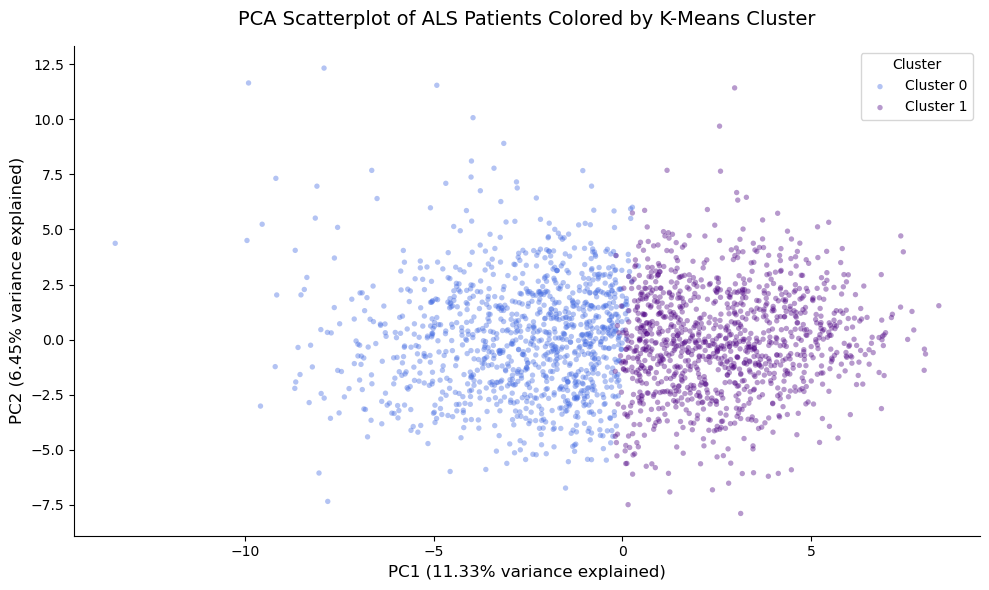

✅ PCA scatterplot complete.


In [26]:
# PCA scatterplot colored by cluster assignment
plt.figure()
colors = [ROYAL_BLUE, PURPLE]

for cluster in sorted(df_pca['cluster'].unique()):
    mask = df_pca['cluster'] == cluster
    plt.scatter(
        df_pca.loc[mask, 'PC1'],
        df_pca.loc[mask, 'PC2'],
        color=colors[cluster],
        alpha=0.4,
        edgecolors='none',
        label=f'Cluster {cluster}',
        s=15
    )

plt.title('PCA Scatterplot of ALS Patients Colored by K-Means Cluster', pad=15)
plt.xlabel(
    f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance explained)')
plt.ylabel(
    f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance explained)')
plt.legend(title='Cluster', frameon=True)
plt.tight_layout()
plt.show()

print('✅ PCA scatterplot complete.')

<div style="page-break-before: always;"></div>

<div style="border: 3px solid black; border-radius: 8px; padding: 20px;">

### Summary

The scatterplot reveals a visually meaningful separation between the two clusters along the PC1 axis. Cluster 0 (blue) occupies the left side of the plot and Cluster 1 (purple) occupies the right side, with a near-clean division occurring at approximately PC1=0. This suggests that the first principal component, which explains 11.33% of the total variance, is acting as the primary decision boundary between the two patient groups.

It is important to note that the two principal components together explain only 17.78% of the total variance in the original 99-feature space. This means the 2D projection captures a limited portion of the full data structure, and some overlap visible in the plot is expected given the dimensionality reduction. The relatively clean split along PC1 despite this limitation suggests the cluster separation is meaningful and would likely appear even more distinct in the full high-dimensional space.

The low silhouette scores observed earlier are therefore at least partly attributable to the high dimensionality and overlapping clinical profiles inherent in ALS patient data, rather than indicating a poor clustering solution. The visual evidence from the PCA plot supports k=2 as a reasonable and interpretable choice for this dataset.

</div>

---
## Final Summary

In [27]:
# Final summary statistics by cluster
print('📋 Cluster Summary Statistics:')
print(f'\n{"Metric":<30} {"Cluster 0":>12} {"Cluster 1":>12}')
print('-' * 56)

key_cols = ['Age_mean', 'ALSFRS_slope', 'ALSFRS_Total_median',
            'onset_delta_mean', 'respiratory_median', 'hands_median',
            'leg_median', 'mouth_median', 'trunk_median']

for col in key_cols:
    c0 = df[df['cluster'] == 0][col].mean()
    c1 = df[df['cluster'] == 1][col].mean()
    print(f'{col:<30} {c0:>12.4f} {c1:>12.4f}')

print(f'\n📊 Cluster sizes:')
print(f'   Cluster 0: {(df["cluster"] == 0).sum():,} patients')
print(f'   Cluster 1: {(df["cluster"] == 1).sum():,} patients')

📋 Cluster Summary Statistics:

Metric                            Cluster 0    Cluster 1
--------------------------------------------------------
Age_mean                            54.4698      54.6304
ALSFRS_slope                        -1.0271      -0.4297
ALSFRS_Total_median                 22.4107      31.7950
onset_delta_mean                  -664.4068    -701.5674
respiratory_median                   3.3960       3.7891
hands_median                         3.5698       6.2399
leg_median                           3.0405       5.0580
mouth_median                         8.8191      10.5868
trunk_median                         3.5558       6.2298

📊 Cluster sizes:
   Cluster 0: 1,111 patients
   Cluster 1: 1,112 patients


<div style="border: 5px solid black; border-radius: 8px; padding: 20px;">
    
### Notebook Summary

This notebook applied K-means clustering to anonymized ALS patient data with the goal of identifying natural patient groupings based on clinical and functional measures. Following the removal of administrative identifier columns and standard scaling of all 99 remaining features, silhouette scores were calculated for k=2 through k=10. Scores were consistently low across all values, ranging from 0.04 to 0.08, reflecting the high dimensionality and overlapping clinical profiles typical of ALS patient datasets. K=2 was selected as the optimal number of clusters as it produced the highest silhouette score of 0.0787 and represented the strongest available separation in the data.

The fitted K-means model produced a nearly balanced split of 1,111 and 1,112 patients across the two clusters. PCA reduction to two components explained 17.78% of the total variance, and the resulting scatterplot revealed a visually meaningful separation between clusters along the PC1 axis, with a near-clean division at approximately PC1=0.

Examination of cluster means across key clinical features reveals a clinically meaningful distinction between the two groups. Age at assessment was nearly identical across both clusters at approximately 54.5 years, indicating that age alone does not drive the separation. Instead, the clusters differ substantially on disease severity and progression. Cluster 0 patients exhibit an ALSFRS slope of -1.03 compared to -0.43 for Cluster 1, indicating Cluster 0 patients are declining at more than twice the rate (2.4x). Cluster 0 also scores consistently lower across all motor subscores including hands, leg, mouth, and trunk, and carries a markedly lower ALSFRS Total median of 22.4 versus 31.8 for Cluster 1. These findings suggest Cluster 0 represents patients with more advanced or rapidly progressing ALS while Cluster 1 represents patients with milder or slower progressing disease.

The low silhouette scores should be understood in the context of high-dimensional clinical data rather than as an indication of a poor model fit. The visual and quantitative evidence together support k=2 as a meaningful and interpretable clustering solution for this patient population. 

</div>

<div style="border: 5px solid green; border-radius: 8px; padding: 20px;">

## Reflection

### Overall Reflection
This assignment strengthened my understanding of the full clustering workflow, from data preparation through model evaluation and visualization. Working with a high‑dimensional clinical dataset highlighted the importance of thoughtful preprocessing, careful interpretation of unsupervised results, and clear communication of uncertainty. After reviewing the instructor’s feedback, I recognize that my conclusions should have been framed with more analytical restraint, especially given the low silhouette scores. The exercise reinforced that clustering in medical datasets is exploratory by nature, and interpretations must be presented cautiously unless supported by stronger validation.

### Straightforward Aspects
Several parts of the workflow felt intuitive and aligned well with prior experience. Removing administrative identifiers such as ID and SubjectID was clear, and applying a standard scaler was a familiar preprocessing step for algorithms like K‑means. Generating silhouette scores across a range of cluster values and producing the PCA scatterplot were also straightforward, and the visualizations helped confirm the numerical patterns. Implementing the K‑means model itself was technically simple once the data was scaled and cleaned.

### More Challenging Aspects
The most challenging part was interpreting the clustering results responsibly. The silhouette scores were consistently low, indicating weak separation, yet my initial write‑up leaned too confidently toward meaningful clinical distinctions. The feedback helped me see that I should have explicitly acknowledged the limitations of the dataset and the method, emphasizing that any cluster differences are exploratory rather than validated patient subtypes. Another challenge was articulating why each retained variable was relevant to ALS progression; I removed irrelevant identifiers but did not clearly justify the clinical relevance of the remaining features. Going forward, I will be more deliberate about explaining feature choices and more cautious about drawing conclusions from unsupervised models with limited structure.

</div>